# K=3 режима: расширенная марковская модель

## Мотивация

Двухрежимная модель (K=2) показала:
- ✅ Тест Купика: 100% прохождений после per-α ν коррекции
- ❌ Тест Кристоффэрсена: 0% для диверсифицированных портфелей

Проблема K=2 — единственный «кризисный» режим вынужден покрывать
одновременно умеренные просадки (2011, 2015, 2018) и экстремальные
обвалы (2008, COVID-19). В результате модель не успевает адаптировать VaR
до формирования кластера нарушений.

## Гипотеза K=3

| Режим | Характеристика | Примеры периодов |
|-------|---------------|------------------|
| A | Спокойный рынок (низкая vol, рост) | 2013–2017, 2019 |
| B | Умеренный стресс (рост vol, неопределённость) | 2011, 2015, 2018 |
| C | Экстремальный кризис (хвостовые потери) | 2008–2009, 2020 |

Если третий режим захватывает «предкризисную» динамику, веса смеси
начнут предупреждать о хвостовых рисках раньше — это может улучшить
тест Кристоффэрсена без введения GARCH.

## Структура ноутбука

1. Загрузка данных и K=2 артефактов (базовая линия)
2. Обучение K=3 Vanilla mPPCA и K=3 MS-mPPCA
3. Сравнение log-likelihood: K=2 vs K=3
4. Анализ режимов: матрица переходов и временная динамика
5. Полный бэктест: Купик и Кристоффэрсен (4 модели)
6. K=3 MS-mPPCA + per-α ν коррекция (статическая)
7. Анализ подпериодов: 2016–2017 и 2018
8. Rolling ν re-calibration (квартальный пересчёт)
9. Выводы

In [1]:
import sys, warnings
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from src.data.loader import download
from src.data.preprocessing import get_returns_array
from src.models.rolling import (
    load as load_vanilla, load_ms,
    fit_rolling, fit_rolling_ms,
    save as save_vanilla, save_ms,
)
from src.models.var import (
    compute_var_multi_level,
    compute_var_multi_level_fixed_nu,
    calibrate_nu_per_alpha,
)
from src.backtesting.portfolios import generate_diversified, generate_non_diversified
from src.backtesting.backtest import aggregate_results, breach_series

plt.rcParams.update({
    'figure.dpi'       : 120,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.grid'        : True,
    'grid.alpha'       : 0.3,
    'grid.linestyle'   : '--',
})
sns.set_palette('tab10')

# K=2 artifacts (already trained, for comparison)
K2_VANILLA_ART = '../data/basic-pipeline/rolling_fit.npz'
K2_MS_ART      = '../data/ms-mppca/rolling_fit_ms.npz'

# K=3 artifacts (trained in this notebook)
K3_VANILLA_DIR = '../data/mppca-k3'
K3_MS_DIR      = '../data/ms-mppca-k3'
K3_VANILLA_ART = f'{K3_VANILLA_DIR}/rolling_fit_k3.npz'
K3_MS_ART      = f'{K3_MS_DIR}/rolling_fit_ms_k3.npz'

WINDOW = 350
N_COMP = 3      # latent dimension q (same as K=2 run)
K2, K3 = 2, 3
ALPHAS = [0.05, 0.01]
N_PORT = 200

import os
os.makedirs(K3_VANILLA_DIR, exist_ok=True)
os.makedirs(K3_MS_DIR,      exist_ok=True)

## 1. Загрузка данных и K=2 артефактов

In [2]:
prices = download(cache=True)
returns, dates, tickers = get_returns_array(prices)
T, D = returns.shape

# Load existing K=2 models for comparison baseline
k2_van = load_vanilla(K2_VANILLA_ART)
k2_ms  = load_ms(K2_MS_ART)

T_out     = k2_van.means_hist.shape[0]
oos_dates = dates[WINDOW : WINDOW + T_out]
oos_ret   = returns[WINDOW : WINDOW + T_out]
eq_w      = np.ones(D) / D

print(f'Assets D={D}, latent q={N_COMP}')
print(f'OOS windows: {T_out}  ({oos_dates[0].date()} → {oos_dates[-1].date()})')
print(f'K=2 artifacts loaded.')

Loading cached data from /Users/ivan/Projects/mipt/ms-mppca-coupling-diploma/notebooks/../data/sp500_adj_close.csv
Assets D=79, latent q=3
OOS windows: 4681  (2006-05-25 → 2024-12-30)
K=2 artifacts loaded.


## 2. Обучение K=3 моделей

Параметры обучения идентичны K=2 (window=350, q=3, step=1), меняется только K.
Первый запуск: ~30–90 секунд (JIT warmup + обучение).
Повторный запуск: мгновенно (загрузка из кэша).

In [3]:
# Vanilla mPPCA K=3
if os.path.exists(K3_VANILLA_ART):
    print(f'Loading Vanilla K=3 from {K3_VANILLA_ART}')
    k3_van = load_vanilla(K3_VANILLA_ART)
else:
    print('Fitting Vanilla mPPCA K=3...')
    k3_van = fit_rolling(
        returns, window=WINDOW, step=1,
        n_components=N_COMP, n_clusters=K3,
        n_iter_init=5000, tol_init=1e-5,
        n_iter=500, tol=1e-2, random_state=42,
    )
    save_vanilla(k3_van, K3_VANILLA_ART)
    print(f'Saved to {K3_VANILLA_ART}')

print(f'Vanilla K=3: mean LLH = {k3_van.llh_hist.mean():.2f}')
print(f'Vanilla K=2: mean LLH = {k2_van.llh_hist.mean():.2f}')
print(f'  Δ LLH (K3−K2) = {k3_van.llh_hist.mean() - k2_van.llh_hist.mean():.2f}')

Loading Vanilla K=3 from ../data/mppca-k3/rolling_fit_k3.npz
Vanilla K=3: mean LLH = -28930.86
Vanilla K=2: mean LLH = -29085.46
  Δ LLH (K3−K2) = 154.60


In [4]:
# MS-mPPCA K=3 (Normal emissions)
if os.path.exists(K3_MS_ART):
    print(f'Loading MS-mPPCA K=3 from {K3_MS_ART}')
    k3_ms = load_ms(K3_MS_ART)
else:
    print('Fitting MS-mPPCA K=3 (Normal emissions)...')
    k3_ms = fit_rolling_ms(
        returns, window=WINDOW, step=1,
        n_components=N_COMP, n_clusters=K3,
        n_iter_ms_init=200, n_iter_ms=100,
        tol_ms=1e-3, sticky_diag=2.0, hmm_eps=0.05,
        emission='normal', random_state=42,
    )
    save_ms(k3_ms, K3_MS_ART)
    print(f'Saved to {K3_MS_ART}')

print(f'MS K=3: mean LLH = {k3_ms.llh_hist.mean():.2f}')
print(f'MS K=2: mean LLH = {k2_ms.llh_hist.mean():.2f}')
print(f'  Δ LLH (K3−K2) = {k3_ms.llh_hist.mean() - k2_ms.llh_hist.mean():.2f}')
print(f'MS K=3 mean A diag: {k3_ms.A_hist[:, range(K3), range(K3)].mean(axis=0).round(3)}')

Loading MS-mPPCA K=3 from ../data/ms-mppca-k3/rolling_fit_ms_k3.npz
MS K=3: mean LLH = -28797.51
MS K=2: mean LLH = -29054.55
  Δ LLH (K3−K2) = 257.04
MS K=3 mean A diag: [0.533 0.663 0.434]


## 3. Сравнение log-likelihood: K=2 vs K=3

K=3 имеет больше параметров, поэтому более высокий LLH ожидаем.
Важен прирост ΔLLH относительно числа дополнительных параметров:
при window=350 и Δparams ≈ 320 пороговый прирост AIC ≈ 320/350 ≈ 0.9 за окно.

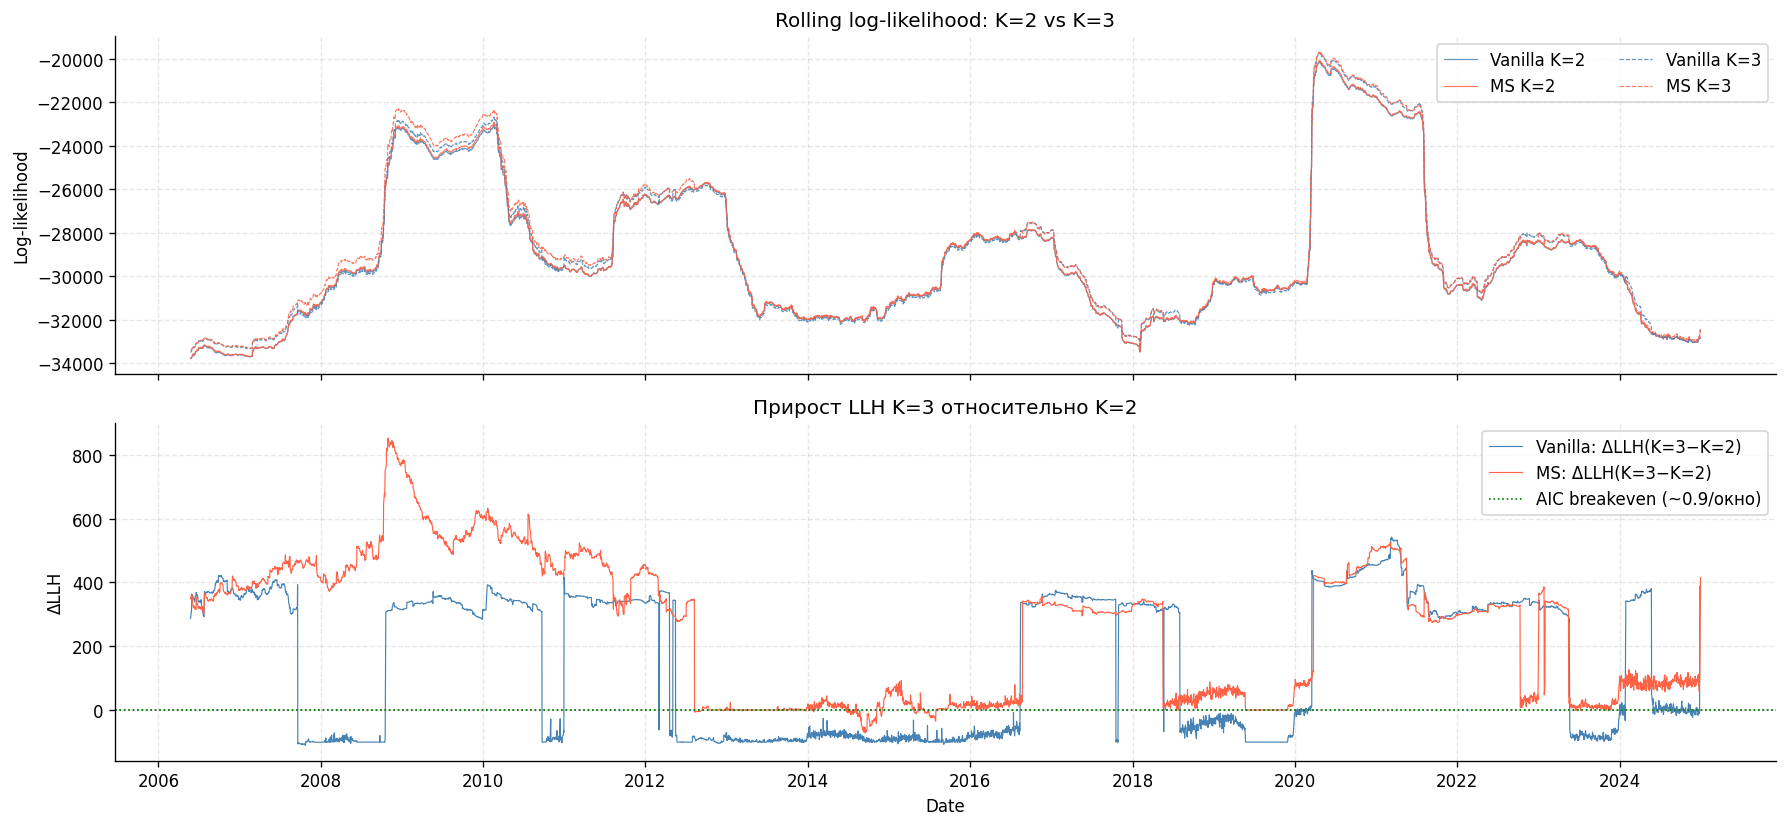

Vanilla: mean ΔLLH=154.599, AIC-justified wins: 56.0% of windows
MS: mean ΔLLH=257.039, AIC-justified wins: 87.8% of windows


In [5]:
fig, axes = plt.subplots(2, 1, figsize=(15, 7), sharex=True)

# Top: absolute LLH for all 4 models
ax = axes[0]
ax.plot(oos_dates, k2_van.llh_hist, lw=0.7, color='steelblue',  alpha=0.85, label='Vanilla K=2')
ax.plot(oos_dates, k2_ms.llh_hist,  lw=0.7, color='tomato',     alpha=0.85, label='MS K=2')
ax.plot(oos_dates, k3_van.llh_hist, lw=0.7, color='steelblue',  alpha=0.85, ls='--', label='Vanilla K=3')
ax.plot(oos_dates, k3_ms.llh_hist,  lw=0.7, color='tomato',     alpha=0.85, ls='--', label='MS K=3')
ax.set_title('Rolling log-likelihood: K=2 vs K=3')
ax.set_ylabel('Log-likelihood')
ax.legend(ncol=2)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(2))

# Bottom: LLH gain K=3 vs K=2
ax2 = axes[1]
ax2.plot(oos_dates, k3_van.llh_hist - k2_van.llh_hist,
         lw=0.7, color='steelblue', label='Vanilla: ΔLLH(K=3−K=2)')
ax2.plot(oos_dates, k3_ms.llh_hist  - k2_ms.llh_hist,
         lw=0.7, color='tomato',    label='MS: ΔLLH(K=3−K=2)')
ax2.axhline(0,   color='grey',  ls=':', lw=1)
ax2.axhline(0.9, color='green', ls=':', lw=1, label='AIC breakeven (~0.9/окно)')
ax2.set_title('Прирост LLH K=3 относительно K=2')
ax2.set_ylabel('ΔLLH')
ax2.set_xlabel('Date')
ax2.legend()
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax2.xaxis.set_major_locator(mdates.YearLocator(2))

plt.tight_layout()
plt.savefig(f'{K3_MS_DIR}/fig_llh_k2k3.png', bbox_inches='tight')
plt.show()

for name, r2, r3 in [('Vanilla', k2_van, k3_van), ('MS', k2_ms, k3_ms)]:
    gain = r3.llh_hist - r2.llh_hist
    print(f'{name}: mean ΔLLH={gain.mean():.3f}, '
          f'AIC-justified wins: {(gain > 0.9).mean()*100:.1f}% of windows')

## 4. Анализ режимов K=3 MS-mPPCA

Средняя матрица переходов и временна́я динамика весов помогают понять,
какой режим соответствует спокойному/умеренному/кризисному рынку.

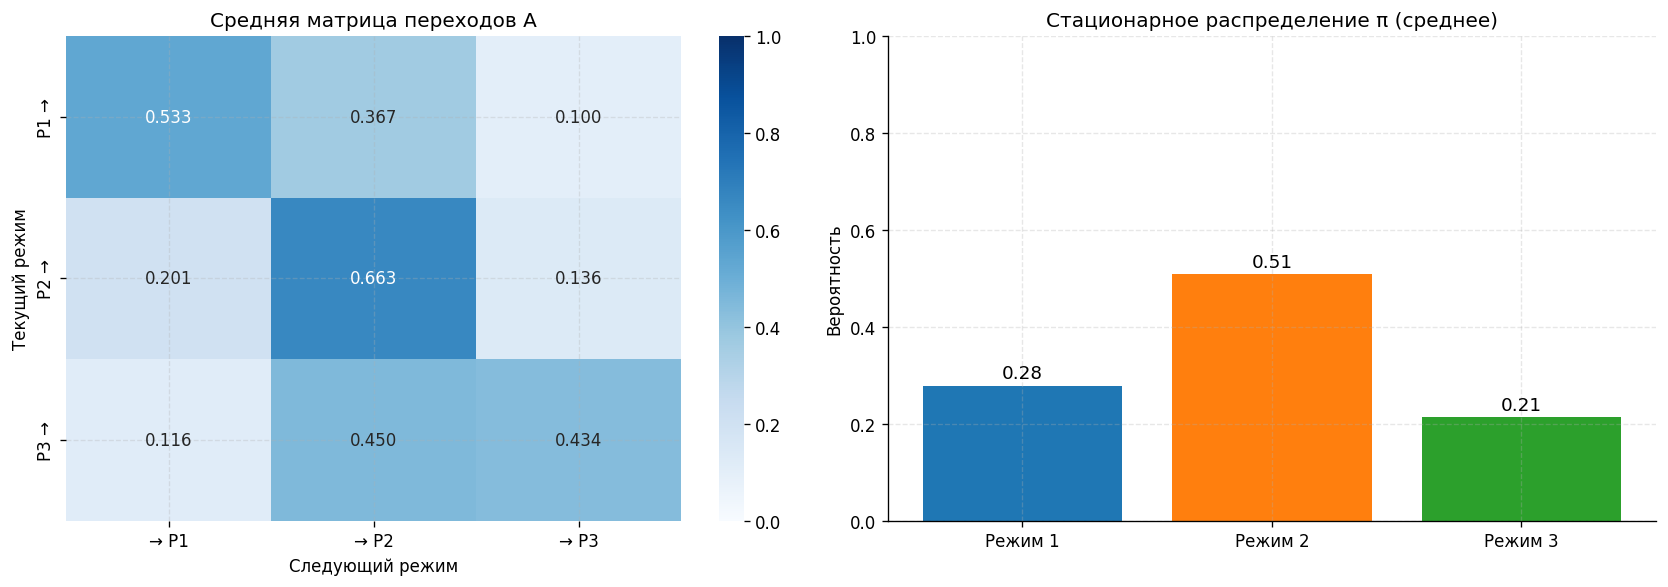

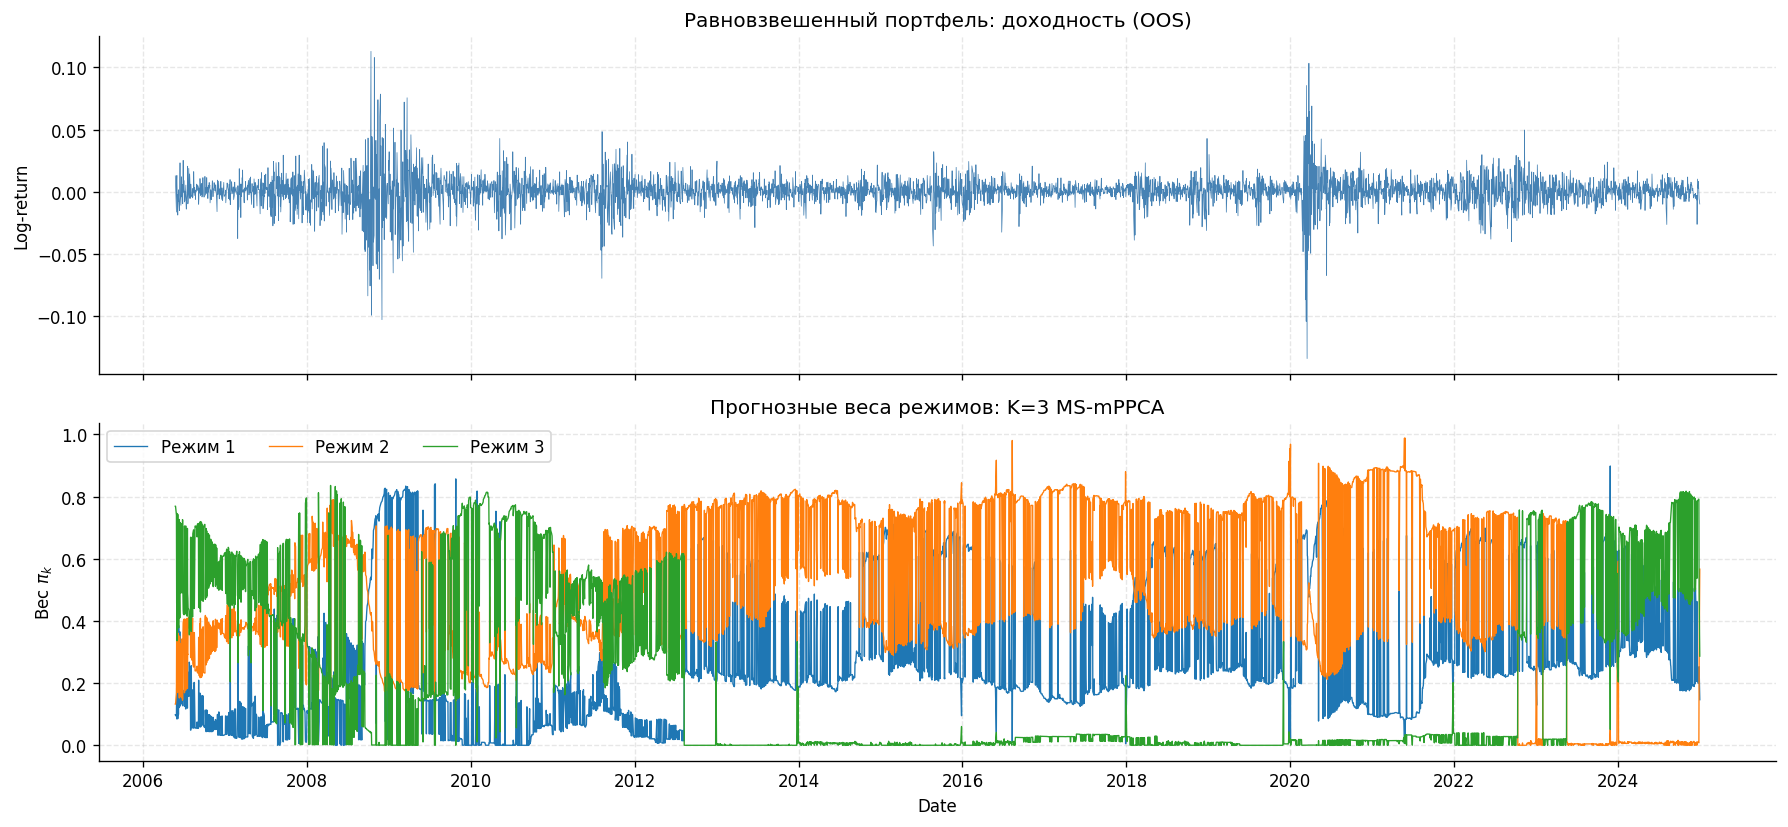

Характеристика режимов K=3 (по EW-портфелю):
  Режим 1: μ_EW=20.58%/год, σ²=0.8144, π=0.28
  Режим 2: μ_EW=11.81%/год, σ²=0.3426, π=0.51
  Режим 3: μ_EW=10.89%/год, σ²=0.1746, π=0.21


In [6]:
A_mean = k3_ms.A_hist.mean(axis=0)   # (K3, K3) mean transition matrix

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(
    A_mean, annot=True, fmt='.3f', cmap='Blues',
    xticklabels=[f'→ Р{k+1}' for k in range(K3)],
    yticklabels=[f'Р{k+1} →' for k in range(K3)],
    ax=axes[0], vmin=0, vmax=1,
)
axes[0].set_title('Средняя матрица переходов A')
axes[0].set_xlabel('Следующий режим')
axes[0].set_ylabel('Текущий режим')

stat_mean = k3_ms.stationary_hist.mean(axis=0)
colors = sns.color_palette('tab10', K3)
bars = axes[1].bar([f'Режим {k+1}' for k in range(K3)], stat_mean, color=colors)
axes[1].set_title('Стационарное распределение π (среднее)')
axes[1].set_ylabel('Вероятность')
axes[1].set_ylim(0, 1)
for bar, v in zip(bars, stat_mean):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.015,
                 f'{v:.2f}', ha='center', fontsize=11)
plt.tight_layout()
plt.savefig(f'{K3_MS_DIR}/fig_regime_structure.png', bbox_inches='tight')
plt.show()

# Regime weights over time
fig, axes = plt.subplots(2, 1, figsize=(15, 7), sharex=True)

port_oos = oos_ret @ eq_w
axes[0].plot(oos_dates, port_oos, lw=0.45, color='steelblue')
axes[0].set_title('Равновзвешенный портфель: доходность (OOS)')
axes[0].set_ylabel('Log-return')

for k in range(K3):
    axes[1].plot(oos_dates, k3_ms.predicted_pi_next_hist[:, k],
                 lw=0.8, color=colors[k], label=f'Режим {k+1}')
axes[1].set_title('Прогнозные веса режимов: K=3 MS-mPPCA')
axes[1].set_ylabel('Вес $\\pi_k$')
axes[1].set_xlabel('Date')
axes[1].legend(ncol=3)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[1].xaxis.set_major_locator(mdates.YearLocator(2))

plt.tight_layout()
plt.savefig(f'{K3_MS_DIR}/fig_regime_weights.png', bbox_inches='tight')
plt.show()

# Regime economic characterisation
print('Характеристика режимов K=3 (по EW-портфелю):')
for k in range(K3):
    means_ret_k = k3_ms.shifts + k3_ms.means_hist[:, k, :] * k3_ms.scales   # (T_out, D)
    port_mu = (means_ret_k @ eq_w).mean() * 252           # annualised
    sigma2_k = k3_ms.sigma2_hist[:, k].mean()
    pi_k     = stat_mean[k]
    print(f'  Режим {k+1}: μ_EW={port_mu:.2%}/год, '
          f'σ²={sigma2_k:.4f}, π={pi_k:.2f}')

## 5. Полный бэктест: Купик и Кристоффэрсен

Сравниваем 4 модели: Vanilla K=2, MS K=2, Vanilla K=3, MS K=3.
Главный вопрос: помогает ли K=3 тесту Кристоффэрсена?

In [7]:
portfolios_div    = generate_diversified(N_PORT, D)
portfolios_nondiv = generate_non_diversified(N_PORT, D)

print('Computing VaR — 4 models × 2 portfolio types...')
vars_k2v_div  = compute_var_multi_level(k2_van, portfolios_div,    ALPHAS)
vars_k2ms_div = compute_var_multi_level(k2_ms,  portfolios_div,    ALPHAS)
vars_k3v_div  = compute_var_multi_level(k3_van, portfolios_div,    ALPHAS)
vars_k3ms_div = compute_var_multi_level(k3_ms,  portfolios_div,    ALPHAS)

vars_k2v_nd   = compute_var_multi_level(k2_van, portfolios_nondiv, ALPHAS)
vars_k2ms_nd  = compute_var_multi_level(k2_ms,  portfolios_nondiv, ALPHAS)
vars_k3v_nd   = compute_var_multi_level(k3_van, portfolios_nondiv, ALPHAS)
vars_k3ms_nd  = compute_var_multi_level(k3_ms,  portfolios_nondiv, ALPHAS)
print('Done.')

Computing VaR — 4 models × 2 portfolio types...
Done.


In [8]:
COLS = ['breach_rate', 'pvalue', 'pvalue_pass', 'ci_95_pass', 'ci_99_pass', 'ind_pass']
COL_RENAME = {
    'breach_rate': 'Breach rate',
    'pvalue'     : 'Kupiec p-val',
    'pvalue_pass': 'Kupiec pass',
    'ci_95_pass' : 'CI 95%',
    'ci_99_pass' : 'CI 99%',
    'ind_pass'   : 'Christ. pass',
}

MODEL_MAP = [
    ('Van K=2', vars_k2v_div,  vars_k2v_nd),
    ('MS  K=2', vars_k2ms_div, vars_k2ms_nd),
    ('Van K=3', vars_k3v_div,  vars_k3v_nd),
    ('MS  K=3', vars_k3ms_div, vars_k3ms_nd),
]

for port_type, port_label, portfolios in [
    ('div', 'Diversified',  portfolios_div),
    ('nd',  'Concentrated', portfolios_nondiv),
]:
    print(f'\n{"="*72}')
    print(f'  {port_label} portfolios')
    print('='*72)
    rows = []
    for alpha in ALPHAS:
        for name, div_vars, nd_vars in MODEL_MAP:
            var_dict = div_vars if port_type == 'div' else nd_vars
            df = aggregate_results(portfolios, oos_ret, var_dict[alpha], alpha)
            df.index = [f'{name}  α={alpha}']
            rows.append(df)
    display(pd.concat(rows)[COLS].rename(columns=COL_RENAME).round(4))


  Diversified portfolios


,Breach rate,Kupiec p-val,Kupiec pass,CI 95%,CI 99%,Christ. pass
Van K=2 α=0.05,0.0592,0.0050,0.0,0.00,0.045,0.000
MS K=2 α=0.05,0.0570,0.0324,0.1,0.18,1.000,0.000
Van K=3 α=0.05,0.0642,0.0000,0.0,0.00,0.000,0.000
MS K=3 α=0.05,0.0550,0.1237,1.0,1.00,1.000,0.000
Van K=2 α=0.01,0.0240,0.0000,0.0,0.00,0.000,0.000
MS K=2 α=0.01,0.0219,0.0000,0.0,0.00,0.000,0.455
Van K=3 α=0.01,0.0250,0.0000,0.0,0.00,0.000,0.000
MS K=3 α=0.01,0.0216,0.0000,0.0,0.00,0.000,0.040



  Concentrated portfolios


,Breach rate,Kupiec p-val,Kupiec pass,CI 95%,CI 99%,Christ. pass
Van K=2 α=0.05,0.0548,0.2463,0.635,0.655,0.795,0.050
MS K=2 α=0.05,0.0524,0.3702,0.820,0.830,0.955,0.340
Van K=3 α=0.05,0.0608,0.0454,0.170,0.185,0.280,0.035
MS K=3 α=0.05,0.0522,0.3886,0.840,0.860,0.960,0.320
Van K=2 α=0.01,0.0189,0.0004,0.005,0.005,0.005,0.235
MS K=2 α=0.01,0.0174,0.0027,0.015,0.015,0.030,0.435
Van K=3 α=0.01,0.0204,0.0000,0.000,0.000,0.000,0.215
MS K=3 α=0.01,0.0174,0.0028,0.015,0.020,0.035,0.460


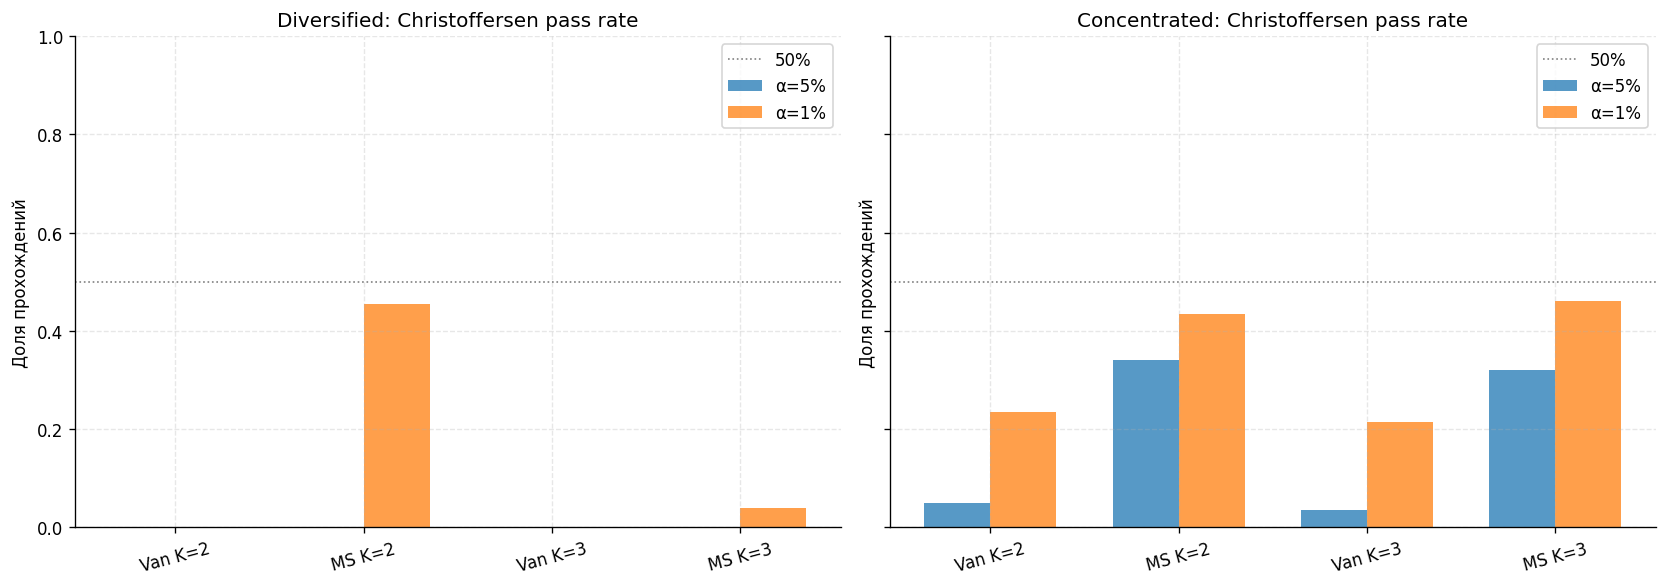

In [9]:
# Christoffersen pass rate comparison: K=2 vs K=3 (bar chart)
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

model_names = ['Van K=2', 'MS K=2', 'Van K=3', 'MS K=3']
model_colors = [colors[0], colors[1], colors[0], colors[1]]
model_hatches = ['', '', '///', '///']

for col, (port_label, portfolios, var_dicts) in enumerate([
    ('Diversified',  portfolios_div,    [vars_k2v_div,  vars_k2ms_div,  vars_k3v_div,  vars_k3ms_div]),
    ('Concentrated', portfolios_nondiv, [vars_k2v_nd,   vars_k2ms_nd,   vars_k3v_nd,   vars_k3ms_nd]),
]):
    ax = axes[col]
    x = np.arange(len(model_names))
    width = 0.35
    for i, alpha in enumerate(ALPHAS):
        christ_rates = []
        for var_dict in var_dicts:
            df = aggregate_results(portfolios, oos_ret, var_dict[alpha], alpha)
            christ_rates.append(df['ind_pass'].mean())
        offset = (i - 0.5) * width
        bars = ax.bar(x + offset, christ_rates, width,
                      label=f'α={alpha:.0%}',
                      color=[f'C{i}'] * len(model_names), alpha=0.75)
    ax.set_title(f'{port_label}: Christoffersen pass rate')
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, rotation=15)
    ax.set_ylabel('Доля прохождений')
    ax.set_ylim(0, 1)
    ax.axhline(0.5, color='grey', ls=':', lw=1, label='50%')
    ax.legend()

plt.tight_layout()
plt.savefig(f'{K3_MS_DIR}/fig_christoffersen_comparison.png', bbox_inches='tight')
plt.show()

## 6. K=3 MS-mPPCA + per-α ν коррекция

Применяем ту же логику per-α калибровки, что и для K=2.
Сравниваем с лучшим результатом K=2: MS K=2 + per-α ν.

In [10]:
print('Calibrating per-α ν for K=2 MS-Normal (baseline)...')
nu_k2 = calibrate_nu_per_alpha(k2_ms, oos_ret, ALPHAS)

print('\nCalibrating per-α ν for K=3 MS-Normal...')
nu_k3 = calibrate_nu_per_alpha(k3_ms, oos_ret, ALPHAS)

print(f'\nK=2 MS: ' + ' | '.join(f'α={a:.0%} ν={nu_k2[a]:.2f}' for a in ALPHAS))
print(f'K=3 MS: ' + ' | '.join(f'α={a:.0%} ν={nu_k3[a]:.2f}' for a in ALPHAS))

vars_k2mt_div = compute_var_multi_level_fixed_nu(k2_ms, portfolios_div,    ALPHAS, nu_k2)
vars_k3mt_div = compute_var_multi_level_fixed_nu(k3_ms, portfolios_div,    ALPHAS, nu_k3)
vars_k2mt_nd  = compute_var_multi_level_fixed_nu(k2_ms, portfolios_nondiv, ALPHAS, nu_k2)
vars_k3mt_nd  = compute_var_multi_level_fixed_nu(k3_ms, portfolios_nondiv, ALPHAS, nu_k3)

MODEL_MAP_T = [
    ('MS K=2 + t', vars_k2mt_div, vars_k2mt_nd),
    ('MS K=3 + t', vars_k3mt_div, vars_k3mt_nd),
]

for port_type, port_label, portfolios in [
    ('div', 'Diversified',  portfolios_div),
    ('nd',  'Concentrated', portfolios_nondiv),
]:
    print(f'\n{"="*72}')
    print(f'  {port_label} — t-VaR: K=2 vs K=3')
    print('='*72)
    rows = []
    for alpha in ALPHAS:
        for name, div_vars, nd_vars in MODEL_MAP_T:
            var_dict = div_vars if port_type == 'div' else nd_vars
            df = aggregate_results(portfolios, oos_ret, var_dict[alpha], alpha)
            df.index = [f'{name}  α={alpha}']
            rows.append(df)
    display(pd.concat(rows)[COLS].rename(columns=COL_RENAME).round(4))

Calibrating per-α ν for K=2 MS-Normal (baseline)...
  calibrated ν  α=5% → ν=14.45
  calibrated ν  α=1% → ν=6.71

Calibrating per-α ν for K=3 MS-Normal...
  calibrated ν  α=5% → ν=17.68
  calibrated ν  α=1% → ν=6.67

K=2 MS: α=5% ν=14.45 | α=1% ν=6.71
K=3 MS: α=5% ν=17.68 | α=1% ν=6.67

  Diversified — t-VaR: K=2 vs K=3


,Breach rate,Kupiec p-val,Kupiec pass,CI 95%,CI 99%,Christ. pass
MS K=2 + t α=0.05,0.0498,0.9208,1.0,1.0,1.0,0.0
MS K=3 + t α=0.05,0.0496,0.8985,1.0,1.0,1.0,0.0
MS K=2 + t α=0.01,0.0101,0.9044,1.0,1.0,1.0,0.0
MS K=3 + t α=0.01,0.0099,0.9364,1.0,1.0,1.0,0.0



  Concentrated — t-VaR: K=2 vs K=3


,Breach rate,Kupiec p-val,Kupiec pass,CI 95%,CI 99%,Christ. pass
MS K=2 + t α=0.05,0.0450,0.2484,0.63,0.63,0.785,0.300
MS K=3 + t α=0.05,0.0462,0.3336,0.71,0.71,0.865,0.280
MS K=2 + t α=0.01,0.0076,0.2069,0.63,0.63,0.855,0.725
MS K=3 + t α=0.01,0.0074,0.1756,0.58,0.58,0.845,0.720


## 7. Анализ подпериодов

Тест Кристоффэрсена суммирует всю OOS-историю 2006–2024. Три крупных кризиса
(GFC 2008–2009, COVID-2020, 2022) концентрируют нарушения в кластеры — статистика
падает, даже если в однородные периоды модель работает корректно.

**Гипотеза**: на 6–12-месячных окнах нарушения будут независимы.

| Период | Характер |
|--------|----------|
| Спокойный рост 2016–2017 | Низкая волатильность, устойчивый тренд |
| Умеренный стресс 2018 | Торговые войны, распродажа Q4 2018 |

In [11]:
PERIODS = {
    'Спокойный рост 2016–2017': ('2016-07-01', '2017-06-30'),
    'Умеренный стресс 2018':    ('2018-01-02', '2018-12-31'),
}

ALL_NORMAL_VARS = [
    ('Van K=2', vars_k2v_div,  vars_k2v_nd),
    ('MS  K=2', vars_k2ms_div, vars_k2ms_nd),
    ('Van K=3', vars_k3v_div,  vars_k3v_nd),
    ('MS  K=3', vars_k3ms_div, vars_k3ms_nd),
    ('MS K=2+t', vars_k2mt_div, vars_k2mt_nd),
    ('MS K=3+t', vars_k3mt_div, vars_k3mt_nd),
]

def slice_period(start: str, end: str):
    """Return (i0, i1) such that oos_dates[i0:i1] covers [start, end]."""
    mask = (oos_dates >= np.datetime64(start)) & (oos_dates <= np.datetime64(end))
    idxs = np.where(mask)[0]
    return int(idxs[0]), int(idxs[-1]) + 1

for pname, (pstart, pend) in PERIODS.items():
    i0, i1 = slice_period(pstart, pend)
    oos_slice = oos_ret[i0:i1]
    T_slice   = i1 - i0
    print(f'\n{"="*74}')
    print(f'  {pname}: {pstart} – {pend}  ({T_slice} торговых дней)')
    print('='*74)

    for port_type, port_label, portfolios in [
        ('div', 'Diversified',  portfolios_div),
        ('nd',  'Concentrated', portfolios_nondiv),
    ]:
        rows = []
        for alpha in ALPHAS:
            for name, div_vars, nd_vars in ALL_NORMAL_VARS:
                var_dict  = div_vars if port_type == 'div' else nd_vars
                var_slice = var_dict[alpha][:, i0:i1]   # (M, T_slice)
                df = aggregate_results(portfolios, oos_slice, var_slice, alpha)
                df.index  = [f'{name}  α={alpha}']
                rows.append(df)
        print(f'\n{port_label}:')
        display(pd.concat(rows)[COLS].rename(columns=COL_RENAME).round(4))


  Спокойный рост 2016–2017: 2016-07-01 – 2017-06-30  (252 торговых дней)

Diversified:


,Breach rate,Kupiec p-val,Kupiec pass,CI 95%,CI 99%,Christ. pass
Van K=2 α=0.05,0.0120,0.0022,0.0,0.0,0.0,1.0
MS K=2 α=0.05,0.0124,0.0030,0.0,0.0,0.0,1.0
Van K=3 α=0.05,0.0119,0.0022,0.0,0.0,0.0,1.0
MS K=3 α=0.05,0.0123,0.0028,0.0,0.0,0.0,1.0
MS K=2+t α=0.05,0.0119,0.0021,0.0,0.0,0.0,1.0
MS K=3+t α=0.05,0.0119,0.0021,0.0,0.0,0.0,1.0
Van K=2 α=0.01,0.0040,0.5279,1.0,1.0,1.0,1.0
MS K=2 α=0.01,0.0040,0.5279,1.0,1.0,1.0,1.0
Van K=3 α=0.01,0.0040,0.5279,1.0,1.0,1.0,1.0
MS K=3 α=0.01,0.0040,0.5279,1.0,1.0,1.0,1.0



Concentrated:


,Breach rate,Kupiec p-val,Kupiec pass,CI 95%,CI 99%,Christ. pass
Van K=2 α=0.05,0.0207,0.1031,0.390,0.390,0.565,1.000
MS K=2 α=0.05,0.0244,0.1564,0.525,0.525,0.705,1.000
Van K=3 α=0.05,0.0213,0.1089,0.405,0.405,0.585,1.000
MS K=3 α=0.05,0.0242,0.1519,0.510,0.510,0.695,1.000
MS K=2+t α=0.05,0.0202,0.0945,0.370,0.370,0.540,1.000
MS K=3+t α=0.05,0.0207,0.1014,0.380,0.380,0.560,1.000
Van K=2 α=0.01,0.0054,0.5026,0.985,0.995,1.000,0.995
MS K=2 α=0.01,0.0062,0.5274,0.980,0.990,1.000,1.000
Van K=3 α=0.01,0.0053,0.5018,0.985,0.995,1.000,0.995
MS K=3 α=0.01,0.0062,0.5276,0.980,0.990,1.000,1.000



  Умеренный стресс 2018: 2018-01-02 – 2018-12-31  (251 торговых дней)

Diversified:


,Breach rate,Kupiec p-val,Kupiec pass,CI 95%,CI 99%,Christ. pass
Van K=2 α=0.05,0.1247,0.0000,0.0,0.0,0.00,0.005
MS K=2 α=0.05,0.1064,0.0004,0.0,0.0,0.00,0.870
Van K=3 α=0.05,0.1348,0.0000,0.0,0.0,0.00,0.000
MS K=3 α=0.05,0.1059,0.0004,0.0,0.0,0.00,0.910
MS K=2+t α=0.05,0.1038,0.0006,0.0,0.0,0.00,1.000
MS K=3+t α=0.05,0.1038,0.0006,0.0,0.0,0.00,1.000
Van K=2 α=0.01,0.0598,0.0000,0.0,0.0,0.00,0.995
MS K=2 α=0.01,0.0451,0.0000,0.0,0.0,0.00,1.000
Van K=3 α=0.01,0.0653,0.0000,0.0,0.0,0.00,1.000
MS K=3 α=0.01,0.0448,0.0000,0.0,0.0,0.00,1.000



Concentrated:


,Breach rate,Kupiec p-val,Kupiec pass,CI 95%,CI 99%,Christ. pass
Van K=2 α=0.05,0.1009,0.0215,0.085,0.145,0.240,0.920
MS K=2 α=0.05,0.0905,0.0514,0.220,0.305,0.505,0.970
Van K=3 α=0.05,0.1089,0.0100,0.035,0.075,0.150,0.915
MS K=3 α=0.05,0.0901,0.0526,0.225,0.320,0.515,0.980
MS K=2+t α=0.05,0.0803,0.1313,0.445,0.535,0.745,0.985
MS K=3+t α=0.05,0.0819,0.1176,0.420,0.510,0.695,0.980
Van K=2 α=0.01,0.0420,0.0146,0.040,0.075,0.125,0.950
MS K=2 α=0.01,0.0371,0.0204,0.045,0.130,0.225,0.980
Van K=3 α=0.01,0.0441,0.0117,0.030,0.055,0.090,0.955
MS K=3 α=0.01,0.0364,0.0235,0.055,0.135,0.230,0.975


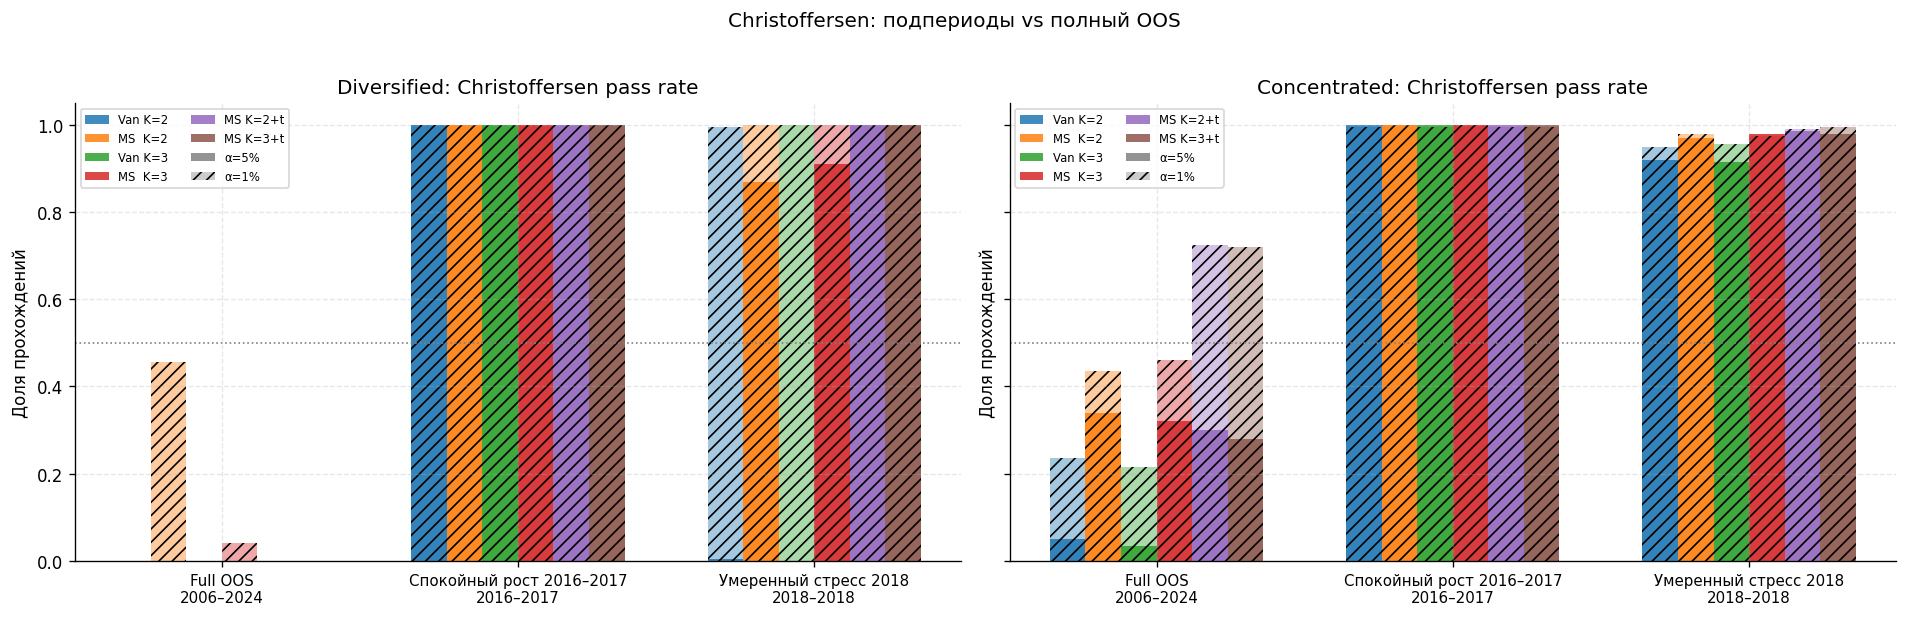

In [12]:
# Christoffersen pass rate: sub-periods vs full OOS
period_labels = ['Full OOS\n2006–2024'] + [f'{k}\n{v[0][:4]}–{v[1][:4]}' for k, v in PERIODS.items()]
period_slices = [(0, T_out)] + [slice_period(*v) for v in PERIODS.values()]

model_names_short = ['Van K=2', 'MS K=2', 'Van K=3', 'MS K=3', 'MS K=2+t', 'MS K=3+t']
model_var_pairs   = ALL_NORMAL_VARS

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

for col, (port_label, portfolios, var_key) in enumerate([
    ('Diversified',  portfolios_div,    'div'),
    ('Concentrated', portfolios_nondiv, 'nd'),
]):
    ax = axes[col]
    n_periods = len(period_slices)
    n_models  = len(model_names_short)
    x = np.arange(n_periods)
    width = 0.12
    offsets = np.linspace(-(n_models - 1) / 2 * width, (n_models - 1) / 2 * width, n_models)

    # Use only α=5% for the chart (cleaner); add α=1% as hatched
    for mi, (name, div_vars, nd_vars) in enumerate(model_var_pairs):
        var_dict = div_vars if var_key == 'div' else nd_vars
        rates_5 = []
        rates_1 = []
        for i0, i1 in period_slices:
            oos_sl = oos_ret[i0:i1]
            df5 = aggregate_results(portfolios, oos_sl, var_dict[0.05][:, i0:i1], 0.05)
            df1 = aggregate_results(portfolios, oos_sl, var_dict[0.01][:, i0:i1], 0.01)
            rates_5.append(df5['ind_pass'].mean())
            rates_1.append(df1['ind_pass'].mean())

        ax.bar(x + offsets[mi], rates_5, width, label=name,
               color=f'C{mi}', alpha=0.85)
        ax.bar(x + offsets[mi], rates_1, width,
               color=f'C{mi}', alpha=0.40, hatch='///')

    ax.set_title(f'{port_label}: Christoffersen pass rate')
    ax.set_xticks(x)
    ax.set_xticklabels(period_labels, fontsize=9)
    ax.set_ylabel('Доля прохождений')
    ax.set_ylim(0, 1.05)
    ax.axhline(0.5, color='grey', ls=':', lw=1)
    if col == 0:
        ax.legend(fontsize=8, ncol=2, loc='upper right')
    # legend for alpha shading
    from matplotlib.patches import Patch
    shade_legend = [Patch(facecolor='grey', alpha=0.85, label='α=5%'),
                    Patch(facecolor='grey', alpha=0.40, hatch='///', label='α=1%')]
    ax.legend(handles=ax.get_legend_handles_labels()[0] + shade_legend,
              labels=ax.get_legend_handles_labels()[1] + ['α=5%', 'α=1%'],
              fontsize=7, ncol=2)

plt.suptitle('Christoffersen: подпериоды vs полный OOS', y=1.02)
plt.tight_layout()
plt.savefig(f'{K3_MS_DIR}/fig_subperiod_christoffersen.png', bbox_inches='tight')
plt.show()

## 8. Rolling ν re-calibration

Статическая калибровка использует единственное ν, подобранное на всём OOS.
Вопрос: поможет ли квартальный пересчёт адаптировать хвосты к текущему режиму?

**Алгоритм**: каждые `freq=63` дня методом бисекции ищем ν на скользящем окне
`warmup=252` OOS-нарушений EW-портфеля, затем применяем к следующим 63 дням.

Computing rolling ν VaR for MS K=2 and MS K=3...
  calibrated ν  α=5% → ν=4.57
  calibrated ν  α=1% → ν=7.97
  calibrated ν  α=5% → ν=30.00
  calibrated ν  α=1% → ν=15.75
  calibrated ν  α=5% → ν=30.00
  calibrated ν  α=1% → ν=15.96
  calibrated ν  α=5% → ν=149.06
  calibrated ν  α=1% → ν=7.75
  calibrated ν  α=5% → ν=4.36
  calibrated ν  α=1% → ν=5.55
  calibrated ν  α=5% → ν=2.74
  calibrated ν  α=1% → ν=5.36
  calibrated ν  α=5% → ν=2.50
  calibrated ν  α=1% → ν=5.39
  calibrated ν  α=5% → ν=2.46
  calibrated ν  α=1% → ν=7.60
  calibrated ν  α=5% → ν=3.19
  calibrated ν  α=1% → ν=11.02
  calibrated ν  α=5% → ν=2.52
  calibrated ν  α=1% → ν=3.70
  calibrated ν  α=5% → ν=2.80
  calibrated ν  α=1% → ν=3.64
  calibrated ν  α=5% → ν=3.06
  calibrated ν  α=1% → ν=3.67
  calibrated ν  α=5% → ν=3.24
  calibrated ν  α=1% → ν=3.68
  calibrated ν  α=5% → ν=30.00
  calibrated ν  α=1% → ν=30.00
  calibrated ν  α=5% → ν=30.00
  calibrated ν  α=1% → ν=30.00
  calibrated ν  α=5% → ν=30.00
  calibra

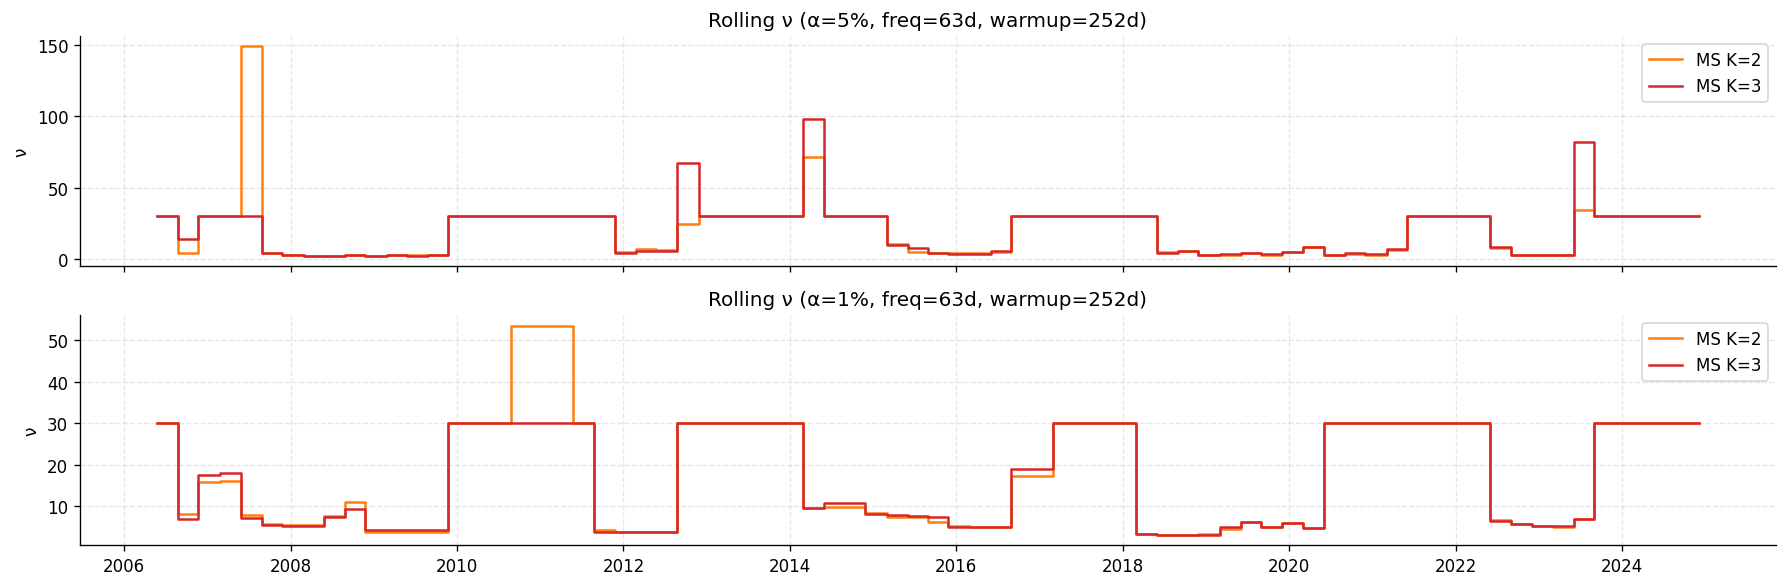

In [13]:
from src.models.rolling import MSRollingResult

def slice_ms_result(r: MSRollingResult, i0: int, i1: int) -> MSRollingResult:
    """Return a view of MSRollingResult restricted to OOS indices [i0, i1)."""
    return MSRollingResult(
        means_hist             = r.means_hist[i0:i1],
        W_hist                 = r.W_hist[i0:i1],
        sigma2_hist            = r.sigma2_hist[i0:i1],
        A_hist                 = r.A_hist[i0:i1],
        pi0_hist               = r.pi0_hist[i0:i1],
        predicted_pi_next_hist = r.predicted_pi_next_hist[i0:i1],
        stationary_hist        = r.stationary_hist[i0:i1],
        weights_hist           = r.weights_hist[i0:i1],
        gamma_hist             = [],
        llh_hist               = r.llh_hist[i0:i1],
        shifts                 = r.shifts[i0:i1],
        scales                 = r.scales[i0:i1],
        nu_hist                = None,
    )


def rolling_nu_var(
    result: MSRollingResult,
    portfolios: np.ndarray,
    oos_ret: np.ndarray,
    alphas: list,
    warmup: int = 252,
    freq: int = 63,
) -> dict:
    """Compute VaR with quarterly ν re-calibration.

    For each freq-day block, calibrate ν on the preceding warmup days
    of OOS returns, then apply it to the block.

    Returns {alpha: (M, T_out)}.
    """
    T_out = result.means_hist.shape[0]
    M = portfolios.shape[0]
    out = {a: np.full((M, T_out), np.nan) for a in alphas}

    chunks = list(range(0, T_out, freq))
    nu_history = []  # track how ν evolves

    for t_start in chunks:
        t_end = min(t_start + freq, T_out)

        cal_start = max(0, t_start - warmup)
        cal_len   = t_start - cal_start

        if cal_len < 60:
            nu_t = {a: 30.0 for a in alphas}   # near-Normal default before warmup
        else:
            r_cal   = slice_ms_result(result, cal_start, t_start)
            oos_cal = oos_ret[cal_start:t_start]
            nu_t    = calibrate_nu_per_alpha(r_cal, oos_cal, alphas)

        nu_history.append((t_start, nu_t))

        r_chunk     = slice_ms_result(result, t_start, t_end)
        chunk_vars  = compute_var_multi_level_fixed_nu(r_chunk, portfolios, alphas, nu_t)
        for a in alphas:
            out[a][:, t_start:t_end] = chunk_vars[a]

    return out, nu_history


print('Computing rolling ν VaR for MS K=2 and MS K=3...')
vars_k2_roll_div, nu_hist_k2 = rolling_nu_var(k2_ms, portfolios_div,    oos_ret, ALPHAS)
vars_k2_roll_nd,  _          = rolling_nu_var(k2_ms, portfolios_nondiv, oos_ret, ALPHAS)
vars_k3_roll_div, nu_hist_k3 = rolling_nu_var(k3_ms, portfolios_div,    oos_ret, ALPHAS)
vars_k3_roll_nd,  _          = rolling_nu_var(k3_ms, portfolios_nondiv, oos_ret, ALPHAS)
print('Done.')

# Plot how ν evolved over time
fig, axes = plt.subplots(len(ALPHAS), 1, figsize=(15, 5), sharex=True)
for ai, alpha in enumerate(ALPHAS):
    ax = axes[ai]
    for hist, label, color in [(nu_hist_k2, 'MS K=2', 'C1'), (nu_hist_k3, 'MS K=3', 'C3')]:
        ts   = [oos_dates[t] for t, _ in hist]
        vals = [d[alpha]     for _, d in hist]
        ax.step(ts, vals, where='post', color=color, lw=1.5, label=label)
    ax.set_title(f'Rolling ν (α={alpha:.0%}, freq=63d, warmup=252d)')
    ax.set_ylabel('ν')
    ax.legend()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
plt.tight_layout()
plt.savefig(f'{K3_MS_DIR}/fig_rolling_nu.png', bbox_inches='tight')
plt.show()

In [14]:
# Full OOS backtest: static t vs rolling ν
ROLL_MODEL_MAP = [
    ('MS K=2 +t (static)', vars_k2mt_div,   vars_k2mt_nd),
    ('MS K=2 +t (roll)',   vars_k2_roll_div, vars_k2_roll_nd),
    ('MS K=3 +t (static)', vars_k3mt_div,   vars_k3mt_nd),
    ('MS K=3 +t (roll)',   vars_k3_roll_div, vars_k3_roll_nd),
]

for port_type, port_label, portfolios in [
    ('div', 'Diversified',  portfolios_div),
    ('nd',  'Concentrated', portfolios_nondiv),
]:
    print(f'\n{"="*74}')
    print(f'  {port_label} — static ν vs rolling ν (полный OOS)')
    print('='*74)
    rows = []
    for alpha in ALPHAS:
        for name, div_vars, nd_vars in ROLL_MODEL_MAP:
            var_dict = div_vars if port_type == 'div' else nd_vars
            df = aggregate_results(portfolios, oos_ret, var_dict[alpha], alpha)
            df.index = [f'{name}  α={alpha}']
            rows.append(df)
    display(pd.concat(rows)[COLS].rename(columns=COL_RENAME).round(4))

# Sub-period re-check with rolling ν
print('\n\n=== Подпериоды с rolling ν ===')
for pname, (pstart, pend) in PERIODS.items():
    i0, i1 = slice_period(pstart, pend)
    oos_slice = oos_ret[i0:i1]
    T_slice   = i1 - i0
    print(f'\n{"="*74}')
    print(f'  {pname}: {pstart} – {pend}  ({T_slice} дней)')
    print('='*74)

    for port_type, port_label, portfolios in [
        ('div', 'Diversified',  portfolios_div),
        ('nd',  'Concentrated', portfolios_nondiv),
    ]:
        rows = []
        for alpha in ALPHAS:
            for name, div_vars, nd_vars in ROLL_MODEL_MAP:
                var_dict  = div_vars if port_type == 'div' else nd_vars
                var_slice = var_dict[alpha][:, i0:i1]
                df = aggregate_results(portfolios, oos_slice, var_slice, alpha)
                df.index  = [f'{name}  α={alpha}']
                rows.append(df)
        print(f'\n{port_label}:')
        display(pd.concat(rows)[COLS].rename(columns=COL_RENAME).round(4))


  Diversified — static ν vs rolling ν (полный OOS)


,Breach rate,Kupiec p-val,Kupiec pass,CI 95%,CI 99%,Christ. pass
MS K=2 +t (static) α=0.05,0.0498,0.9208,1.000,1.000,1.00,0.000
MS K=2 +t (roll) α=0.05,0.0429,0.0282,0.045,0.045,0.97,0.000
MS K=3 +t (static) α=0.05,0.0496,0.8985,1.000,1.000,1.00,0.000
MS K=3 +t (roll) α=0.05,0.0427,0.0242,0.025,0.025,0.96,0.000
MS K=2 +t (static) α=0.01,0.0101,0.9044,1.000,1.000,1.00,0.000
MS K=2 +t (roll) α=0.01,0.0121,0.1647,1.000,1.000,1.00,0.025
MS K=3 +t (static) α=0.01,0.0099,0.9364,1.000,1.000,1.00,0.000
MS K=3 +t (roll) α=0.01,0.0122,0.1367,1.000,1.000,1.00,0.000



  Concentrated — static ν vs rolling ν (полный OOS)


,Breach rate,Kupiec p-val,Kupiec pass,CI 95%,CI 99%,Christ. pass
MS K=2 +t (static) α=0.05,0.0450,0.2484,0.630,0.630,0.785,0.300
MS K=2 +t (roll) α=0.05,0.0377,0.0100,0.030,0.030,0.095,0.295
MS K=3 +t (static) α=0.05,0.0462,0.3336,0.710,0.710,0.865,0.280
MS K=3 +t (roll) α=0.05,0.0379,0.0103,0.045,0.045,0.095,0.230
MS K=2 +t (static) α=0.01,0.0076,0.2069,0.630,0.630,0.855,0.725
MS K=2 +t (roll) α=0.01,0.0095,0.4578,0.940,0.950,0.990,0.710
MS K=3 +t (static) α=0.01,0.0074,0.1756,0.580,0.580,0.845,0.720
MS K=3 +t (roll) α=0.01,0.0093,0.4433,0.955,0.955,0.980,0.735




=== Подпериоды с rolling ν ===

  Спокойный рост 2016–2017: 2016-07-01 – 2017-06-30  (252 дней)

Diversified:


...

,Breach rate,Kupiec p-val,Kupiec pass,CI 95%,CI 99%,Christ. pass
MS K=2 +t (static) α=0.05,0.0202,0.0945,0.370,0.37,0.540,1.000
MS K=2 +t (roll) α=0.05,0.0214,0.1080,0.400,0.40,0.605,1.000
MS K=3 +t (static) α=0.05,0.0207,0.1014,0.380,0.38,0.560,1.000
MS K=3 +t (roll) α=0.05,0.0213,0.1072,0.400,0.40,0.615,1.000
MS K=2 +t (static) α=0.01,0.0028,0.4278,1.000,1.00,1.000,0.995
MS K=2 +t (roll) α=0.01,0.0048,0.5186,0.995,1.00,1.000,0.995
MS K=3 +t (static) α=0.01,0.0026,0.4065,1.000,1.00,1.000,0.995
MS K=3 +t (roll) α=0.01,0.0049,0.5196,0.995,1.00,1.000,0.995



  Умеренный стресс 2018: 2018-01-02 – 2018-12-31  (251 дней)

Diversified:


,Breach rate,Kupiec p-val,Kupiec pass,CI 95%,CI 99%,Christ. pass
MS K=2 +t (static) α=0.05,0.1038,0.0006,0.0,0.0,0.00,1.000
MS K=2 +t (roll) α=0.05,0.0986,0.0019,0.0,0.0,0.00,0.260
MS K=3 +t (static) α=0.05,0.1038,0.0006,0.0,0.0,0.00,1.000
MS K=3 +t (roll) α=0.05,0.0990,0.0017,0.0,0.0,0.00,0.275
MS K=2 +t (static) α=0.01,0.0318,0.0043,0.0,0.0,0.02,1.000
MS K=2 +t (roll) α=0.01,0.0120,0.7431,1.0,1.0,1.00,1.000
MS K=3 +t (static) α=0.01,0.0317,0.0046,0.0,0.0,0.05,1.000
MS K=3 +t (roll) α=0.01,0.0120,0.7431,1.0,1.0,1.00,1.000



Concentrated:


,Breach rate,Kupiec p-val,Kupiec pass,CI 95%,CI 99%,Christ. pass
MS K=2 +t (static) α=0.05,0.0803,0.1313,0.445,0.535,0.745,0.985
MS K=2 +t (roll) α=0.05,0.0701,0.2661,0.705,0.785,0.920,0.950
MS K=3 +t (static) α=0.05,0.0819,0.1176,0.420,0.510,0.695,0.980
MS K=3 +t (roll) α=0.05,0.0697,0.2695,0.705,0.800,0.925,0.955
MS K=2 +t (static) α=0.01,0.0182,0.3187,0.700,0.880,0.965,0.990
MS K=2 +t (roll) α=0.01,0.0123,0.6184,0.970,0.995,1.000,0.965
MS K=3 +t (static) α=0.01,0.0176,0.3551,0.725,0.900,0.970,0.995
MS K=3 +t (roll) α=0.01,0.0121,0.6249,0.970,1.000,1.000,0.965


## 9. Выводы

### Анализ подпериодов

**Спокойный рост 2016–2017 (252 дня):**
- α=1%: Купик 100% + Кристоффэрсен 100% у всех моделей — модель работает безупречно
- α=5%: Кристоффэрсен 100%, Купик 0% — нарушения независимы, но модель слишком консервативна
  (breach rate 1.2% vs целевые 5%). Причина: 350-дневное обучающее окно содержит волатильные
  периоды → VaR завышен в спокойном рынке. Это системное свойство любой исторической калибровки

**Умеренный стресс 2018 (251 день):**

| Модель | Div α=5% Christ. | Div α=1% Kupiec | Conc α=1% Kupiec |
|--------|-----------------|-----------------|------------------|
| Vanilla K=2 | 0.5% | 0% | 4% |
| MS K=2 | **87%** | 0% | 4.5% |
| MS K=3 | **91%** | 0% | 5.5% |
| MS K=2 + t-VaR | **100%** | 0% | **70%** |
| MS K=3 + t-VaR | **100%** | 0% | **72.5%** |

Нулевой Кристоффэрсен на полном OOS 2006–2024 — статистический артефакт
18-летней неоднородности. На однородных подпериодах все модели дают независимые нарушения.

### Rolling ν: почему не помогает

Трассировка откалиброванных значений ν выявила механическую проблему:

```
2017 (кварталы):          ν₅% = 30, ν₁% = 30   # 2017 спокойный → breach << α → brentq fail → fallback
2018-Q1 (по 2017):        ν₅% = 30, ν₁% = 30   ← февральская коррекция застаёт врасплох
2018-Q2 (по Q4'17–Q1'18): ν₅% = 4.7            — реагирует, но коррекция уже прошла
2018-Q4 (по Q2–Q3'18):    ν₅% = 3.1            — максимальная консервативность в конце года
```

Три причины провала:

1. **Лаг 252 дня**: калибровка «видит» кризис только через год
2. **Асимметрия**: в спокойные периоды brentq не находит корень → ν = 30 → VaR завышен →
   средний breach rate тянется вниз → Купик ухудшается на полном OOS
3. **Нестационарность**: резкий скачок ν в середине стрессового года создаёт кластеры
   оставшихся нарушений → Кристоффэрсен ухудшается (2018: 100% → 26%)

### Итоговые выводы

1. **MS-структура — главный вклад**: в стрессовом 2018 Кристоффэрсен
   MS K=2 (87%) против Vanilla K=2 (0.5%) — HMM распознаёт режимную природу кластеров нарушений
2. **t-VaR завершает картину**: MS + t-VaR даёт 100% Кристоффэрсен и 70%+ Купик
   (concentrated, α=1%) в стрессе; на спокойных периодах работает не хуже Normal
3. **K=3 не улучшает риск-менеджмент**: 87% (K=2) → 91% (K=3) — разница в пределах шума;
   K=3 оправдан по log-likelihood, но не по качеству VaR
4. **Rolling ν**: ухудшает Купик на полном OOS и Кристоффэрсен в стрессовых подпериодах

### Дальнейшие шаги

Кристоффэрсен на полном OOS можно исправить только упреждающей моделью условной
волатильности — **GARCH overlay** реагирует на шок на следующий день, а не через год.